# **Section 1 — Imports**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


# **Section 2 — Load & Clean Data**

In [ ]:
df = pd.read_csv('weatherAUS.csv')
print(f" Raw data shape: {df.shape}")
print(f"Target distribution:\n{df['RainTomorrow'].value_counts()}\n")

df = df.dropna(subset=['RainTomorrow'])

if 'Date' in df.columns:
    df = df.drop('Date', axis=1)

for col in df.select_dtypes(include='float64').columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)
    df[col] = LabelEncoder().fit_transform(df[col])

print(f" Cleaned data shape: {df.shape}")
print(f"Missing values remaining: {df.isnull().sum().sum()}")

 Raw data shape: (32897, 23)
Target distribution:
RainTomorrow
No     25050
Yes     7160
Name: count, dtype: int64

 Cleaned data shape: (32210, 22)
Missing values remaining: 0


# **Section 3 — Exploratory Data Analysis (EDA)**

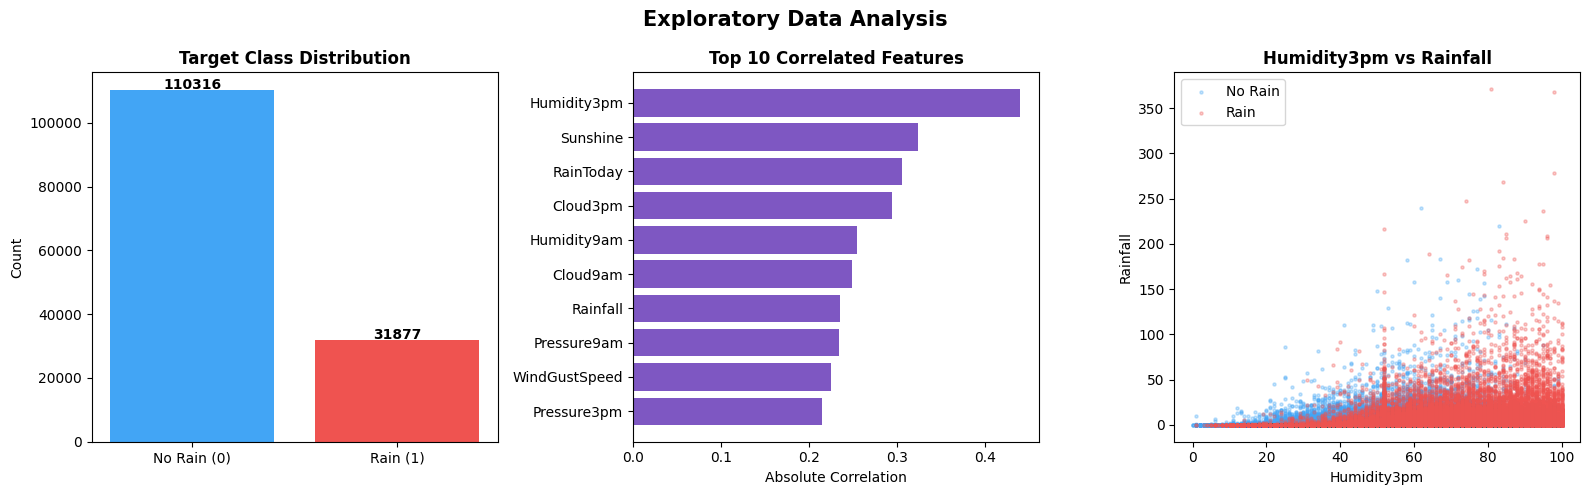

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Exploratory Data Analysis", fontsize=15, fontweight='bold')

# 1. Target Distribution
counts = df['RainTomorrow'].value_counts()
axes[0].bar(['No Rain (0)', 'Rain (1)'], counts.values, color=['#42A5F5', '#EF5350'])
axes[0].set_title("Target Class Distribution", fontweight='bold')
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# 2. Top correlated features
corr = df.corr()['RainTomorrow'].abs().sort_values(ascending=False)[1:11]
axes[1].barh(corr.index[::-1], corr.values[::-1], color='#7E57C2')
axes[1].set_title("Top 10 Correlated Features", fontweight='bold')
axes[1].set_xlabel("Absolute Correlation")

# 3. Humidity vs Rainfall scatter
axes[2].scatter(df[df['RainTomorrow']==0]['Humidity3pm'],
                df[df['RainTomorrow']==0]['Rainfall'],
                alpha=0.3, s=5, color='#42A5F5', label='No Rain')
axes[2].scatter(df[df['RainTomorrow']==1]['Humidity3pm'],
                df[df['RainTomorrow']==1]['Rainfall'],
                alpha=0.3, s=5, color='#EF5350', label='Rain')
axes[2].set_title("Humidity3pm vs Rainfall", fontweight='bold')
axes[2].set_xlabel("Humidity3pm")
axes[2].set_ylabel("Rainfall")
axes[2].legend()

plt.tight_layout()
plt.show()

# **Section 4 — Split & Scale**

In [ ]:
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

print(f"Train size: {X_train_raw.shape[0]} | Test size: {X_test_raw.shape[0]}")
print(f"Original feature count: {X_train_scaled.shape[1]}")

Train size: 113754 | Test size: 28439
Original feature count: 21


# **Section 5 — Dimension Reduction (Selection + PCA)**

In [ ]:
N_SELECT = 15
N_PCA    = 8

# ── Feature Selection ──
selector = SelectKBest(score_func=f_classif, k=N_SELECT)
X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_test_sel  = selector.transform(X_test_scaled)

selected_mask   = selector.get_support()
selected_names  = X.columns[selected_mask].tolist()
selector_scores = selector.scores_[selected_mask]

print(f"✅ Feature Selection: kept {N_SELECT} / {X_train_scaled.shape[1]} features")
print(f"Selected features: {selected_names}")

# ── Feature Extraction (PCA) ──
pca = PCA(n_components=N_PCA, random_state=42)
X_train_pca = pca.fit_transform(X_train_sel)
X_test_pca  = pca.transform(X_test_sel)

print(f"\n✅ PCA: {N_SELECT} → {N_PCA} components")
print(f"Cumulative variance explained: {pca.explained_variance_ratio_.cumsum()[-1]*100:.1f}%")

✅ Feature Selection: kept 15 / 21 features
Selected features: ['MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp3pm', 'RainToday']

✅ PCA: 15 → 8 components
Cumulative variance explained: 86.8%


# **Section 6 — Dimension Reduction Diagrams**

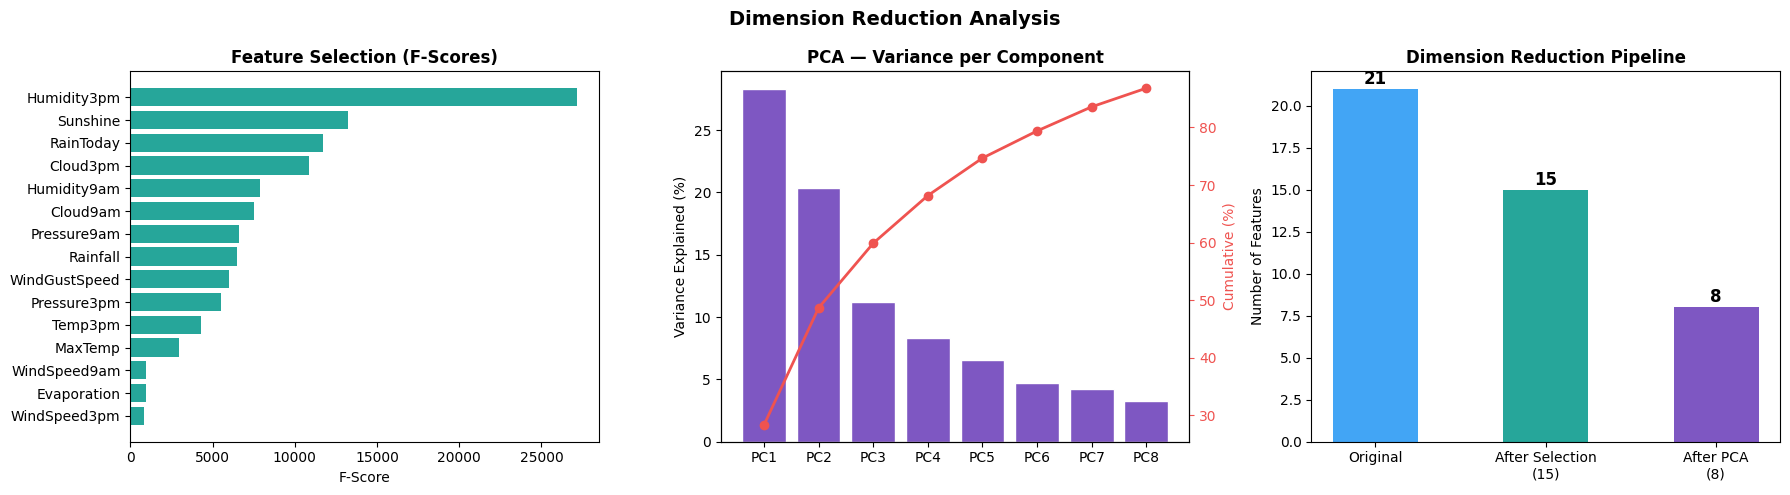

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Dimension Reduction Analysis", fontsize=14, fontweight='bold')

# 1. Feature Selection scores
sorted_idx = np.argsort(selector_scores)[::-1]
axes[0].barh([selected_names[i] for i in sorted_idx[::-1]],
             [selector_scores[i] for i in sorted_idx[::-1]],
             color='#26A69A')
axes[0].set_title("Feature Selection (F-Scores)", fontweight='bold')
axes[0].set_xlabel("F-Score")

# 2. PCA variance per component
comp_labels = [f"PC{i+1}" for i in range(N_PCA)]
axes[1].bar(comp_labels, pca.explained_variance_ratio_ * 100, color='#7E57C2', edgecolor='white')
axes[1].set_title("PCA — Variance per Component", fontweight='bold')
axes[1].set_ylabel("Variance Explained (%)")
ax1b = axes[1].twinx()
ax1b.plot(comp_labels, pca.explained_variance_ratio_.cumsum() * 100,
          color='#EF5350', marker='o', linewidth=2)
ax1b.set_ylabel("Cumulative (%)", color='#EF5350')
ax1b.tick_params(colors='#EF5350')

# 3. Pipeline: feature count reduction
stages     = ['Original', f'After Selection\n({N_SELECT})', f'After PCA\n({N_PCA})']
counts_dim = [X_train_scaled.shape[1], N_SELECT, N_PCA]
colors_dim = ['#42A5F5', '#26A69A', '#7E57C2']
bars = axes[2].bar(stages, counts_dim, color=colors_dim, width=0.5)
axes[2].set_title("Dimension Reduction Pipeline", fontweight='bold')
axes[2].set_ylabel("Number of Features")
for bar, val in zip(bars, counts_dim):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3, str(val),
                 ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# **Section 7 — Train All Models (Baseline + Reduced)**

In [ ]:
model_names = ['Random Forest', 'Logistic Regression']

def train_and_eval(X_tr, X_te, y_tr, y_te, label):
    res = {}
    for name, model in [
        ('Random Forest',       RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                                        random_state=42, n_jobs=-1)),
        ('Logistic Regression', LogisticRegression(max_iter=1000, class_weight='balanced',
                                                    random_state=42))
    ]:
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]
        res[name] = {
            'model':    model,
            'y_pred':   y_pred,
            'y_prob':   y_prob,
            'Accuracy': accuracy_score(y_te, y_pred) * 100,
            'ROC-AUC':  roc_auc_score(y_te, y_prob) * 100,
        }
        print(f"  [{label}] {name}: Acc={res[name]['Accuracy']:.2f}%  AUC={res[name]['ROC-AUC']:.2f}%")
    return res

print("⚙️ Training BASELINE (original features)...")
results_baseline = train_and_eval(X_train_scaled, X_test_scaled, y_train, y_test, "BASELINE")

print("\n⚙️ Training REDUCED (PCA features)...")
results_reduced  = train_and_eval(X_train_pca, X_test_pca, y_train, y_test, "REDUCED")

print("\n✅ All models trained!")

⚙️ Training BASELINE (original features)...
  [BASELINE] Random Forest: Acc=85.44%  AUC=88.84%
  [BASELINE] Logistic Regression: Acc=79.02%  AUC=86.66%

⚙️ Training REDUCED (PCA features)...
  [REDUCED] Random Forest: Acc=83.54%  AUC=84.95%
  [REDUCED] Logistic Regression: Acc=76.93%  AUC=84.46%

✅ All models trained!


# **Section 8 — Before vs After Comparison**

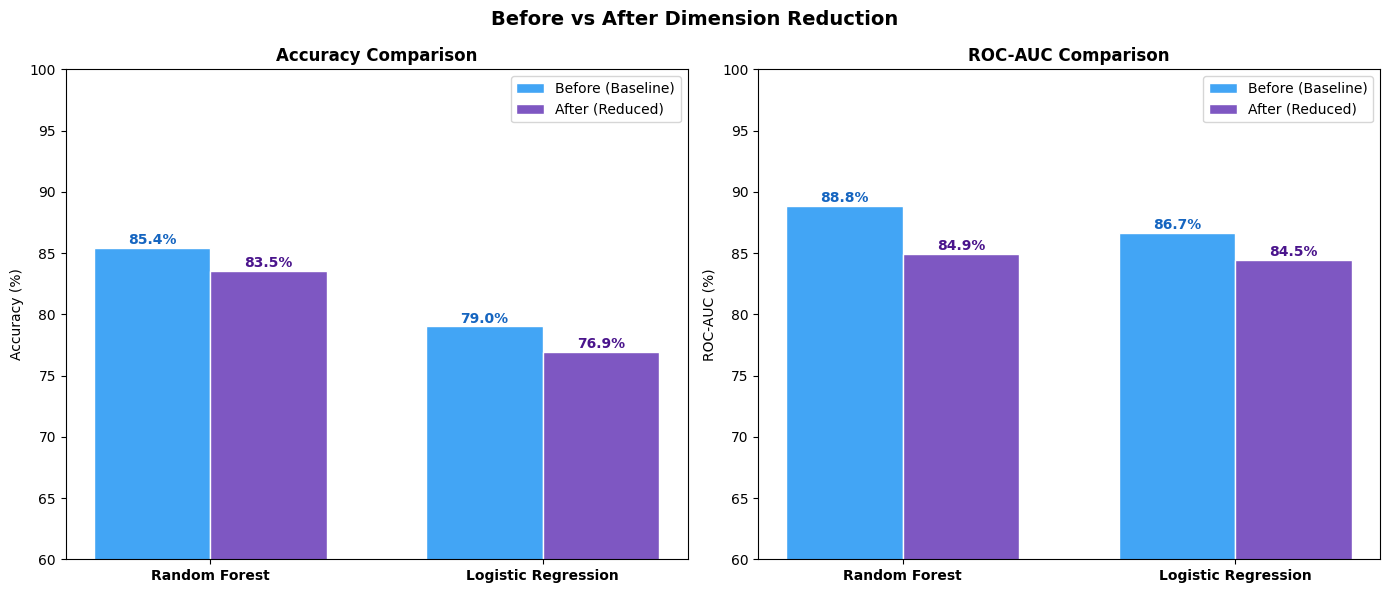


Model                    Acc Before  Acc After    Δ Acc    AUC Before  AUC After    Δ AUC
------------------------------------------------------------------------------------------
Random Forest                85.44%     83.54%   -1.90%        88.84%     84.95%   -3.90%
Logistic Regression          79.02%     76.93%   -2.10%        86.66%     84.46%   -2.20%


In [ ]:
x     = np.arange(len(model_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Before vs After Dimension Reduction", fontsize=14, fontweight='bold')

for ax, metric in zip(axes, ['Accuracy', 'ROC-AUC']):
    before_vals = [results_baseline[m][metric] for m in model_names]
    after_vals  = [results_reduced[m][metric]  for m in model_names]

    bars1 = ax.bar(x - width/2, before_vals, width, label='Before (Baseline)', color='#42A5F5', edgecolor='white')
    bars2 = ax.bar(x + width/2, after_vals,  width, label='After (Reduced)',   color='#7E57C2', edgecolor='white')

    ax.set_title(f"{metric} Comparison", fontweight='bold')
    ax.set_ylabel(f"{metric} (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontweight='bold')
    ax.set_ylim(60, 100)
    ax.legend()

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', fontsize=10,
                fontweight='bold', color='#1565C0')
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', fontsize=10,
                fontweight='bold', color='#4A148C')

plt.tight_layout()
plt.show()

# Difference table
print(f"\n{'Model':<22} {'Acc Before':>12} {'Acc After':>10} {'Δ Acc':>8}  {'AUC Before':>12} {'AUC After':>10} {'Δ AUC':>8}")
print("-" * 90)
for m in model_names:
    da = results_reduced[m]['Accuracy'] - results_baseline[m]['Accuracy']
    dr = results_reduced[m]['ROC-AUC']  - results_baseline[m]['ROC-AUC']
    print(f"{m:<22} {results_baseline[m]['Accuracy']:>11.2f}% {results_reduced[m]['Accuracy']:>9.2f}%  {da:>+6.2f}%  "
          f"{results_baseline[m]['ROC-AUC']:>11.2f}% {results_reduced[m]['ROC-AUC']:>9.2f}%  {dr:>+6.2f}%")

# **Section 9 — Confusion Matrices**

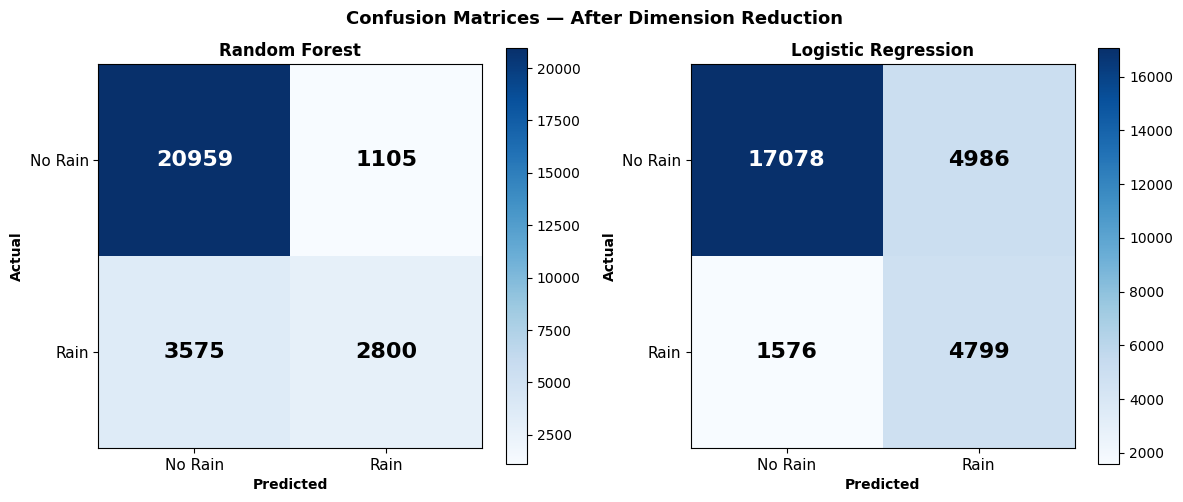

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrices — After Dimension Reduction", fontsize=13, fontweight='bold')

for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_test, results_reduced[name]['y_pred'])
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_xticks([0,1]); ax.set_xticklabels(['No Rain','Rain'], fontsize=11)
    ax.set_yticks([0,1]); ax.set_yticklabels(['No Rain','Rain'], fontsize=11)
    ax.set_xlabel("Predicted", fontweight='bold')
    ax.set_ylabel("Actual",    fontweight='bold')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha='center', va='center',
                    fontsize=16, fontweight='bold',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# **Section 10 — ROC Curves**

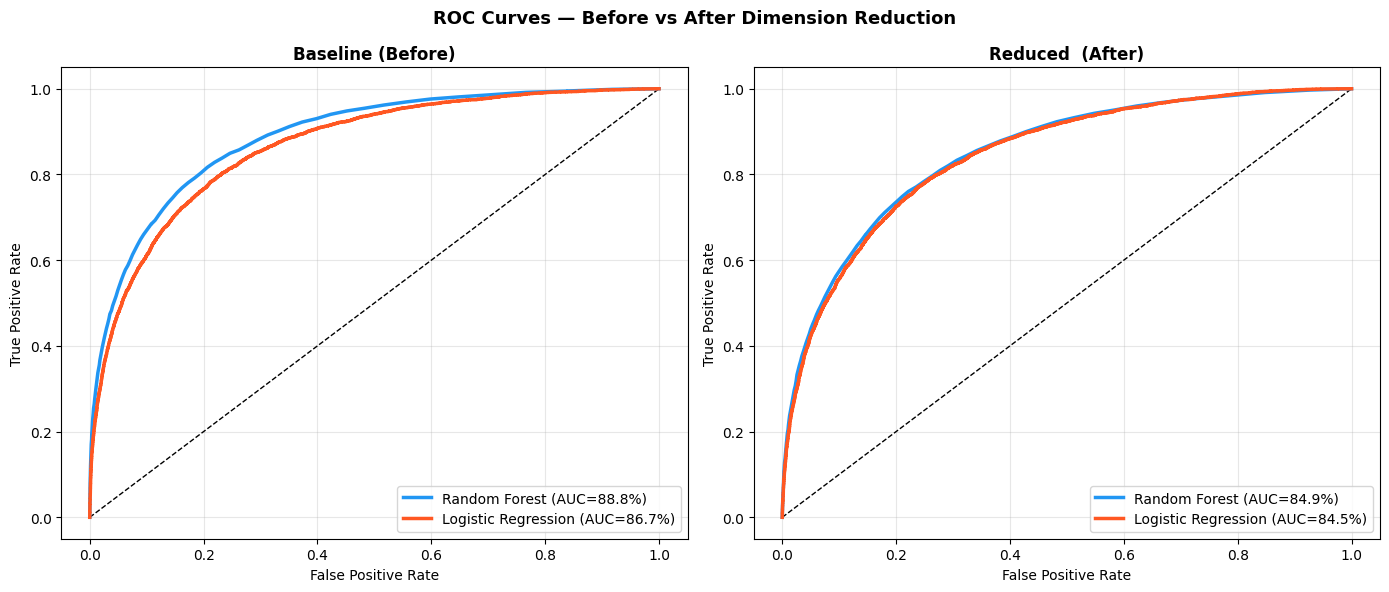

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("ROC Curves — Before vs After Dimension Reduction", fontsize=13, fontweight='bold')
line_colors = {'Random Forest': '#2196F3', 'Logistic Regression': '#FF5722'}

for ax, (label, results) in zip(axes, [('Baseline (Before)', results_baseline),
                                         ('Reduced  (After)',  results_reduced)]):
    ax.plot([0,1],[0,1], 'k--', linewidth=1)
    for name in model_names:
        fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
        ax.plot(fpr, tpr, linewidth=2.5, color=line_colors[name],
                label=f"{name} (AUC={results[name]['ROC-AUC']:.1f}%)")
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **Section 11 — Hyperparameter Tuning**

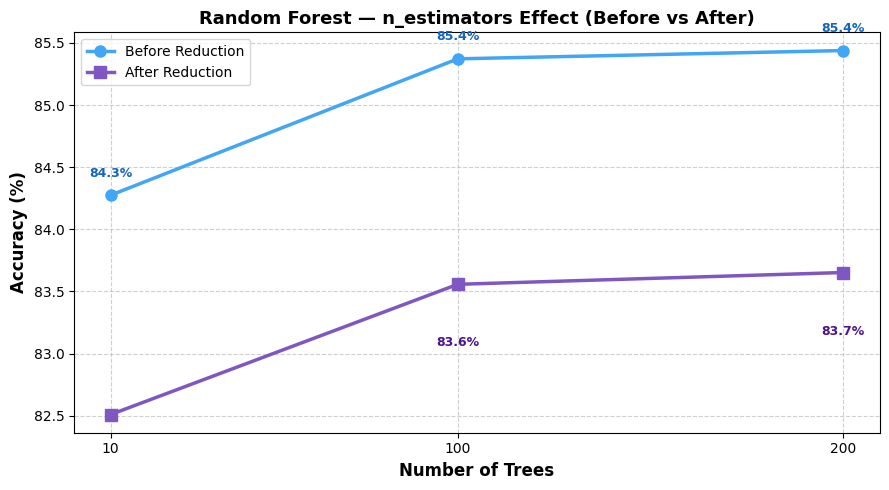

In [ ]:
estimators_range = [10, 100, 200]
acc_before, acc_after = [], []

for n in estimators_range:
    rf_b = RandomForestClassifier(n_estimators=n, max_samples=0.5,
                                   class_weight='balanced', random_state=42, n_jobs=-1)
    rf_b.fit(X_train_scaled, y_train)
    acc_before.append(accuracy_score(y_test, rf_b.predict(X_test_scaled)) * 100)

    rf_a = RandomForestClassifier(n_estimators=n, max_samples=0.5,
                                   class_weight='balanced', random_state=42, n_jobs=-1)
    rf_a.fit(X_train_pca, y_train)
    acc_after.append(accuracy_score(y_test, rf_a.predict(X_test_pca)) * 100)

plt.figure(figsize=(9, 5))
plt.plot(estimators_range, acc_before, marker='o', color='#42A5F5',
         linewidth=2.5, markersize=8, label='Before Reduction')
plt.plot(estimators_range, acc_after,  marker='s', color='#7E57C2',
         linewidth=2.5, markersize=8, label='After Reduction')
plt.title("Random Forest — n_estimators Effect (Before vs After)", fontsize=13, fontweight='bold')
plt.xlabel("Number of Trees", fontsize=12, fontweight='bold')
plt.ylabel("Accuracy (%)",    fontsize=12, fontweight='bold')
plt.xticks(estimators_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
for i, (b, a) in enumerate(zip(acc_before, acc_after)):
    plt.annotate(f"{b:.1f}%", (estimators_range[i], b + 0.15), ha='center', fontsize=9,
                 color='#1565C0', fontweight='bold')
    plt.annotate(f"{a:.1f}%", (estimators_range[i], a - 0.5),  ha='center', fontsize=9,
                 color='#4A148C', fontweight='bold')
plt.tight_layout()
plt.show()

# **Section 12 — Final Results Summary**

  FINAL RESULTS — After Dimension Reduction

🔹 Random Forest
   Accuracy: 83.54%  |  ROC-AUC: 84.95%
              precision    recall  f1-score   support

     No Rain       0.85      0.95      0.90     22064
        Rain       0.72      0.44      0.54      6375

    accuracy                           0.84     28439
   macro avg       0.79      0.69      0.72     28439
weighted avg       0.82      0.84      0.82     28439


🔹 Logistic Regression
   Accuracy: 76.93%  |  ROC-AUC: 84.46%
              precision    recall  f1-score   support

     No Rain       0.92      0.77      0.84     22064
        Rain       0.49      0.75      0.59      6375

    accuracy                           0.77     28439
   macro avg       0.70      0.76      0.72     28439
weighted avg       0.82      0.77      0.78     28439



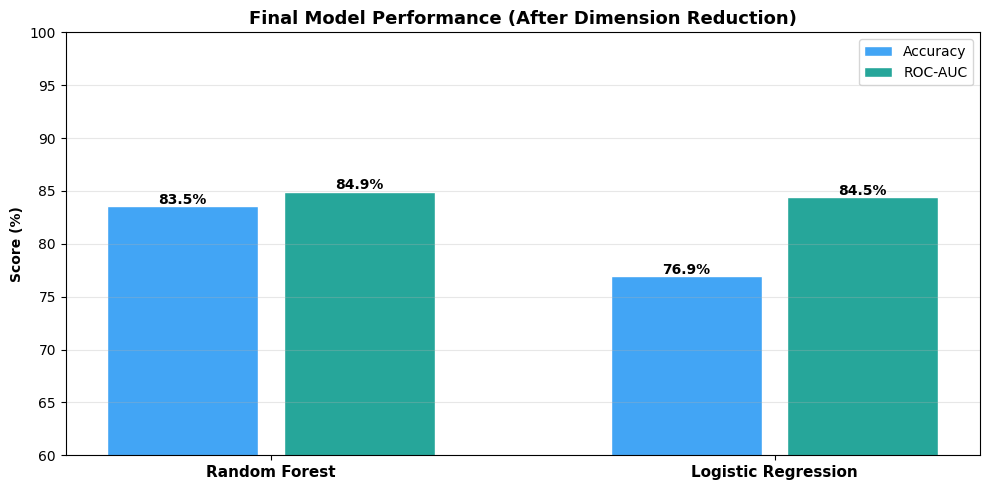

In [ ]:
print("=" * 60)
print("  FINAL RESULTS — After Dimension Reduction")
print("=" * 60)
for name in model_names:
    r = results_reduced[name]
    print(f"\n🔹 {name}")
    print(f"   Accuracy: {r['Accuracy']:.2f}%  |  ROC-AUC: {r['ROC-AUC']:.2f}%")
    print(classification_report(y_test, r['y_pred'], target_names=['No Rain','Rain']))

# Final Summary Bar Chart
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(model_names))

for i, (metric, color) in enumerate(zip(['Accuracy', 'ROC-AUC'], ['#42A5F5', '#26A69A'])):
    vals = [results_reduced[m][metric] for m in model_names]
    bars = ax.bar(x_pos + i * 0.35, vals, 0.3, label=metric, color=color, edgecolor='white')
    for j, v in enumerate(vals):
        ax.text(j + i*0.35, v + 0.2, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x_pos + 0.175)
ax.set_xticklabels(model_names, fontweight='bold', fontsize=11)
ax.set_ylim(60, 100)
ax.set_ylabel("Score (%)", fontweight='bold')
ax.set_title("Final Model Performance (After Dimension Reduction)", fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()